## Group members: Chia-Chun Hsu, Yu-Fong Lin

In [ ]:
import numpy as np
from datetime import datetime

In [ ]:
temp = datetime(2026,1,9)
temp2 = datetime(2028,3,9)
(temp2-temp).days

790

In [ ]:
import numpy as np
import pandas as pd
import time

# ==========================================
# 1. 全域參數設定
# ==========================================
S0 = 6966.28
q = 0.01186
T = 790/365

df_1102028 = 0.936750
df_1102029 = 0.906261
df_3092028 = df_1102028 + (df_1102029 - df_1102028) * 59 / 365
r = -np.log(df_3092028) / T
pay_lag_df = np.exp(-r * (5/365))

# 用來避免浮點數誤差的四捨五入函數
def rnd(x): return round(x, 4)

# ==========================================
# 2. speeding CRR 引擎
# ==========================================
def calculate_crr_price_fast(sigma, steps):
    dt = T / steps
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u
    p = (np.exp((r - q) * dt) - d) / (u - d)
    df_step = np.exp(-r * dt)

    step_jan30 = max(1, int(steps * (21/790)))
    step_autocall = int(steps * (424/790))

    # ---  1：NumPy 矩陣化 Part 2 ---
    def price_after_jan30(S_start, K, current_step):
        steps_left = steps - current_step

        # 1. 一次性產出所有終端價格 (Vectorized)
        j_idx = np.arange(steps_left + 1)
        ST = S_start * (u**j_idx) * (d**(steps_left - j_idx))

        # 2. 一次性計算所有 Payoff
        v = np.where(ST >= K,
                     (1000 + 1000 * 1.5 * (ST/K - 1)) * pay_lag_df,
                     np.where(ST >= 0.8 * K,
                              1000 * pay_lag_df,
                              1000 * (ST/K) * pay_lag_df))

        # 3. 陣列切片 Backward induction
        for i in range(steps_left - 1, -1, -1):
            # 一行取代內層 for 迴圈
            v[:i+1] = df_step * (p * v[1:i+2] + (1-p) * v[:i+1])

            # 處理 Autocall
            if current_step + i == step_autocall:
                j_curr = np.arange(i + 1)
                S_now = S_start * (u**j_curr) * (d**(i - j_curr))
                v[:i+1] = np.where(S_now >= K, 1098.50 * pay_lag_df, v[:i+1])

        return v[0]

    # --- 2：O(1) 字典搜尋 Part 1 ---
    tree = [ {} for _ in range(step_jan30 + 1) ]

    # 1/30 初始化
    for j in range(step_jan30 + 1):
        S_jan30 = S0 * (u**j) * (d**(step_jan30 - j))
        tree[step_jan30][j] = {}

        # M 只會是 S0 * d^k 的組合
        possible_mins = [S0 * (d**k) for k in range(step_jan30 + 1)]
        for M in possible_mins:
            if M <= S_jan30 + 1e-7:
                tree[step_jan30][j][rnd(M)] = price_after_jan30(S_jan30, M, step_jan30)

    # Backward Induction to 1/9
    for i in range(step_jan30 - 1, -1, -1):
        for j in range(i + 1):
            S_now = S0 * (u**j) * (d**(i-j))
            tree[i][j] = {}

            # 在第 i 步，可能的歷史最低價一定是 S0 * d^k (k 從 0 到 i)
            possible_mins = [S0 * (d**k) for k in range(i + 1)]

            for M in possible_mins:
                if M <= S_now + 1e-7:
                    target_M_up = min(M, S_now * u)
                    target_M_down = min(M, S_now * d)

                    # 直接用 rnd() 當作 Key 進行 O(1) 字典取值，完全消滅 lambda 搜尋！
                    V_up = tree[i+1][j+1][rnd(target_M_up)]
                    V_down = tree[i+1][j][rnd(target_M_down)]

                    tree[i][j][rnd(M)] = df_step * (p * V_up + (1 - p) * V_down)

    return tree[0][0][rnd(S0)]

# ==========================================
# 3. 執行 12 種情境測試
# ==========================================
iv_scenarios = {
    "ATM 100% Moneyness": 0.19146,
    "Downside 80% Moneyness": 0.23944,
    "Autocall 424D Term": 0.17770,
    "Initial Set 1/30 Term": 0.11307
}

steps_scenarios = [395, 790, 1580]

results = []

print("開始執行 12 組情境回測...\n")
start_total = time.time()

for iv_name, sigma in iv_scenarios.items():
    row_data = {"IV Scenario": iv_name, "Sigma": f"{sigma*100:.3f}%"}
    for steps in steps_scenarios:
        t0 = time.time()
        price = calculate_crr_price_fast(sigma, steps)
        t1 = time.time()
        row_data[f"Price ({steps} Steps)"] = round(price, 4)
        print(f"[{iv_name}] Steps={steps:4d} | Price={price:8.4f} | 耗時 {t1-t0:.4f} 秒")
    results.append(row_data)

print(f"\n全部執行完畢！總耗時: {time.time() - start_total:.2f} 秒")

# 輸出成 DataFrame
df_results = pd.DataFrame(results)
print("\n--- 價格敏感度矩陣 (Pricing Sensitivity Matrix) ---")
print(df_results.to_markdown(index=False))

開始執行 12 組情境回測...

[ATM 100% Moneyness] Steps= 395 | Price=979.1167 | 耗時 0.2494 秒
[ATM 100% Moneyness] Steps= 790 | Price=980.6271 | 耗時 2.0951 秒
[ATM 100% Moneyness] Steps=1580 | Price=980.8292 | 耗時 20.5155 秒
[Downside 80% Moneyness] Steps= 395 | Price=958.3546 | 耗時 0.2533 秒
[Downside 80% Moneyness] Steps= 790 | Price=960.0899 | 耗時 2.1108 秒
[Downside 80% Moneyness] Steps=1580 | Price=962.0082 | 耗時 20.3858 秒
[Autocall 424D Term] Steps= 395 | Price=982.8380 | 耗時 0.2752 秒
[Autocall 424D Term] Steps= 790 | Price=985.4256 | 耗時 2.0847 秒
[Autocall 424D Term] Steps=1580 | Price=985.5172 | 耗時 19.2329 秒
[Initial Set 1/30 Term] Steps= 395 | Price=1009.8055 | 耗時 0.2558 秒
[Initial Set 1/30 Term] Steps= 790 | Price=1011.0301 | 耗時 4.5428 秒
[Initial Set 1/30 Term] Steps=1580 | Price=1011.6454 | 耗時 23.4786 秒

全部執行完畢！總耗時: 95.48 秒

--- 價格敏感度矩陣 (Pricing Sensitivity Matrix) ---
| IV Scenario            | Sigma   |   Price (395 Steps) |   Price (790 Steps) |   Price (1580 Steps) |
|:-----------------------|:

開始計算大範圍步數，準備畫誤差震盪圖...
基準價格 (N=2000): 981.0434
計算完成，耗時 156.66 秒


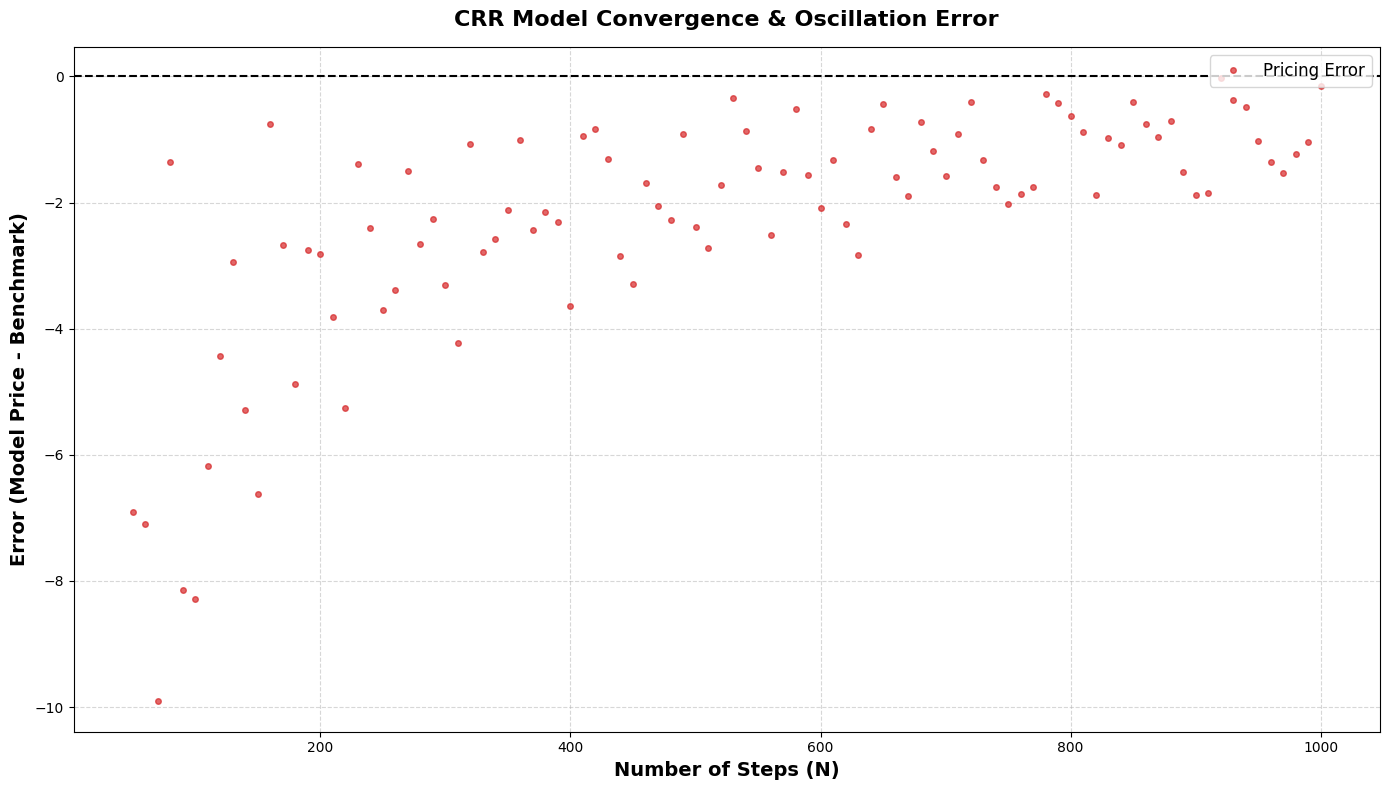

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import time

# ... (這裡請貼上我們前面寫的 S0, r, q, T, pay_lag_df 等全域變數設定) ...
# ... (以及 calculate_crr_price_fast(sigma, steps) 函數) ...

print("開始計算大範圍步數，準備畫誤差震盪圖...")
start_time = time.time()

# 1. 定義測試的步數範圍 (從 50 步到 1000 步，每隔 10 步算一次)
step_list = np.arange(50, 1001, 10)
prices = []

# 固定使用 ATM 的波動率來測試收斂性
test_sigma = 0.19146

# 2. 計算每個步數下的價格
for n in step_list:
    prices.append(calculate_crr_price_fast(test_sigma, n))

# 3. 定義 Benchmark (我們用 1500 步算出來的值當作 "Exact/True Value")
benchmark_price = calculate_crr_price_fast(test_sigma, 2000)
print(f"基準價格 (N=2000): {benchmark_price:.4f}")
print(f"計算完成，耗時 {time.time() - start_time:.2f} 秒")

# 4. 計算誤差 (Error = Model Price - Benchmark Price)
prices = np.array(prices)
errors = prices - benchmark_price

# 5. (Scatter Plot)
fig, ax1 = plt.subplots(figsize=(14, 8))

# 畫出紅色的誤差點
ax1.plot(step_list, errors, 'o', markersize=4, color='tab:red', alpha=0.7, label='Pricing Error')
ax1.axhline(0, color='black', linestyle='--', linewidth=1.5)

ax1.set_title('CRR Model Convergence & Oscillation Error', fontsize=16, fontweight='bold', pad=15)
ax1.set_xlabel('Number of Steps (N)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Error (Model Price - Benchmark)', fontsize=14, fontweight='bold')

ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend(loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

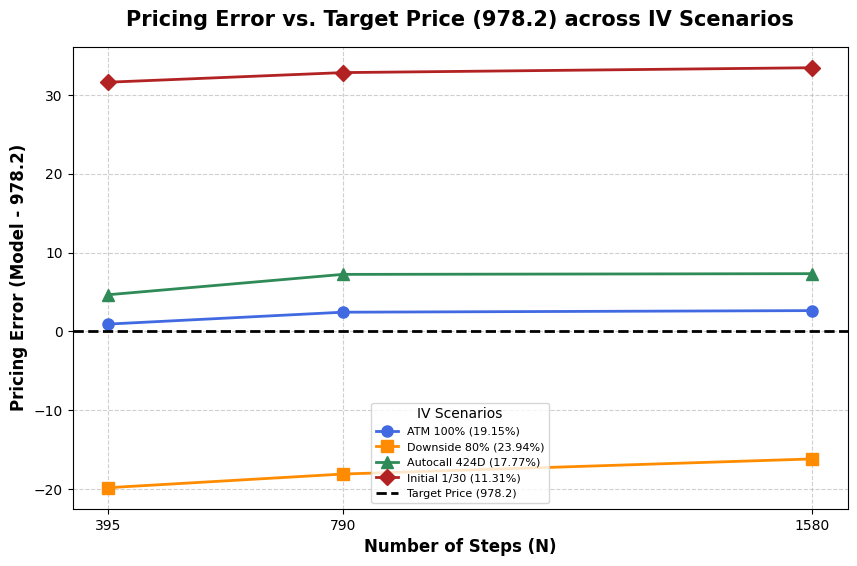

In [ ]:
import matplotlib.pyplot as plt

iv_labels = ['ATM 100% (19.15%)', 'Downside 80% (23.94%)', 'Autocall 424D (17.77%)', 'Initial 1/30 (11.31%)']
steps = [395, 790, 1580]
prices = {
    'ATM 100% (19.15%)': [979.1167, 980.6271, 980.8292],
    'Downside 80% (23.94%)': [958.3546, 960.0899, 962.008],
    'Autocall 424D (17.77%)': [982.838, 985.426, 985.517],
    'Initial 1/30 (11.31%)': [1009.81,1011.03,1011.65]
}

target_price = 978.20

# 計算誤差 (Model Price - Target Price)
errors = {k: [p - target_price for p in v] for k, v in prices.items()}

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['royalblue', 'darkorange', 'seagreen', 'firebrick']
markers = ['o', 's', '^', 'D']

for i, (label, err_list) in enumerate(errors.items()):
    ax.plot(steps, err_list, marker=markers[i], color=colors[i], linewidth=2, markersize=8, label=label)

ax.axhline(0, color='black', linestyle='--', linewidth=2, label='Target Price (978.2)')
ax.set_title('Pricing Error vs. Target Price (978.2) across IV Scenarios', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Number of Steps (N)', fontsize=12, fontweight='bold')
ax.set_ylabel('Pricing Error (Model - 978.2)', fontsize=12, fontweight='bold')
ax.set_xticks(steps)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title='IV Scenarios', fontsize=8)

plt.show()

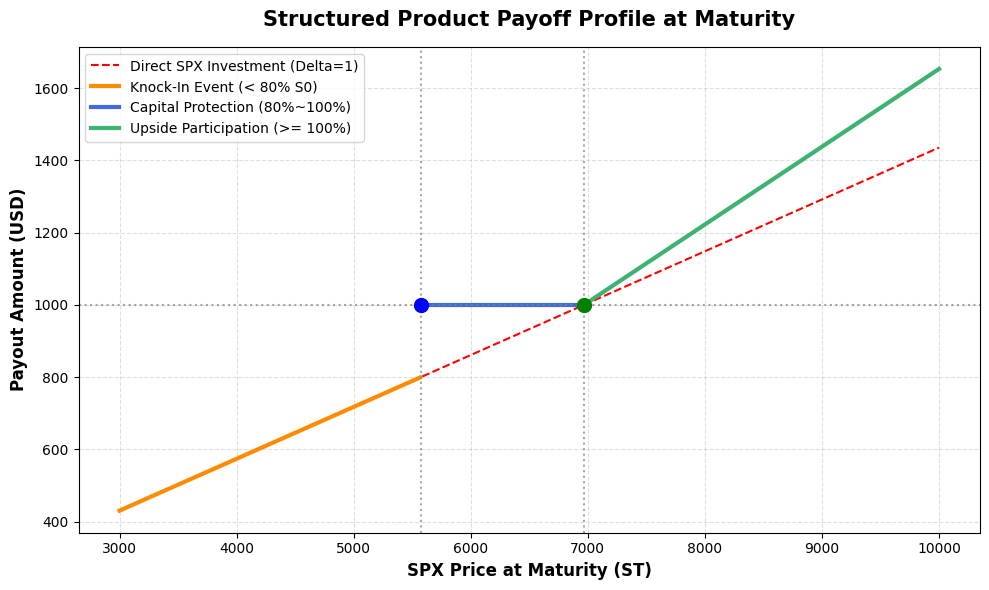

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 商品參數設定
S0 = 6966.28      # 初始 SPX 價格
principal = 1000  # 本金
barrier = 0.8 * S0 # 80% 敲入線 (Knock-in barrier)
gearing = 1.5     # 1.5倍參與率

# 2. 生成 X 軸 (到期股價 ST，範圍設在 3000 到 10000 點)
ST_array = np.linspace(3000, 10000, 500)
payoff_array = np.zeros_like(ST_array)

# 3. 計算每一種 ST 情況下的 Payoff
for i, ST in enumerate(ST_array):
    if ST >= S0:
        # 上漲情況：拿回本金 + 1.5倍的超額報酬
        payoff_array[i] = principal + principal * gearing * (ST/S0 - 1)
    elif ST >= barrier:
        # 下跌但不超過20%：保本
        payoff_array[i] = principal
    else:
        # 暴跌超過20%：敲入，承擔與大盤一樣的虧損
        payoff_array[i] = principal * (ST/S0)

benchmark_payoff = principal * (ST_array / S0)

# 4. 開始畫圖
fig, ax = plt.subplots(figsize=(10, 6))

# 畫出直接投資大盤的基準線 (紅虛線)
ax.plot(ST_array, benchmark_payoff, color='red', linestyle='--', linewidth=1.5, label='Direct SPX Investment (Delta=1)')

# 畫出敲入賠本區 (橘線)
mask_ki = ST_array < barrier
ax.plot(ST_array[mask_ki], payoff_array[mask_ki], color='darkorange', linewidth=3, label='Knock-In Event (< 80% S0)')

# 畫出保本區 (藍線)
mask_safe = (ST_array >= barrier) & (ST_array < S0)
ax.plot(ST_array[mask_safe], payoff_array[mask_safe], color='royalblue', linewidth=3, label='Capital Protection (80%~100%)')

# 畫出上漲獲利區 (綠線)
mask_up = ST_array >= S0
ax.plot(ST_array[mask_up], payoff_array[mask_up], color='mediumseagreen', linewidth=3, label='Upside Participation (>= 100%)')

# 標示轉折點
ax.scatter([S0], [principal], color='green', s=100, zorder=5)
ax.scatter([barrier], [principal], color='blue', s=100, zorder=5)

# 標籤與美化
ax.set_title('Structured Product Payoff Profile at Maturity', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('SPX Price at Maturity (ST)', fontsize=12, fontweight='bold')
ax.set_ylabel('Payout Amount (USD)', fontsize=12, fontweight='bold')

ax.axvline(S0, color='gray', linestyle=':', alpha=0.7)
ax.axvline(barrier, color='gray', linestyle=':', alpha=0.7)
ax.axhline(principal, color='gray', linestyle=':', alpha=0.7)

ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

Monte Carlo Benchmark — ATM 100% Moneyness
  σ                     = 19.146%
  Trials                = 100
  Paths per trial       = 1,000,000
  Total paths           = 100,000,000
  Time-stepping         = 21 daily + 2 big jumps
  Variance reduction    = antithetic

  trial  10/100  running mean = 979.6270  elapsed 16.9s  ETA 151.7s
  trial  20/100  running mean = 979.5889  elapsed 27.5s  ETA 110.1s
  trial  30/100  running mean = 979.6265  elapsed 37.4s  ETA 87.3s
  trial  40/100  running mean = 979.6232  elapsed 46.4s  ETA 69.6s
  trial  50/100  running mean = 979.6122  elapsed 60.5s  ETA 60.5s
  trial  60/100  running mean = 979.5915  elapsed 70.3s  ETA 46.9s
  trial  70/100  running mean = 979.6083  elapsed 80.4s  ETA 34.5s
  trial  80/100  running mean = 979.6215  elapsed 90.1s  ETA 22.5s
  trial  90/100  running mean = 979.6235  elapsed 99.3s  ETA 11.0s
  trial 100/100  running mean = 979.6232  elapsed 108.8s  ETA 0.0s

Statistics across 100 trials:
  Mean         = 979.6232
  S

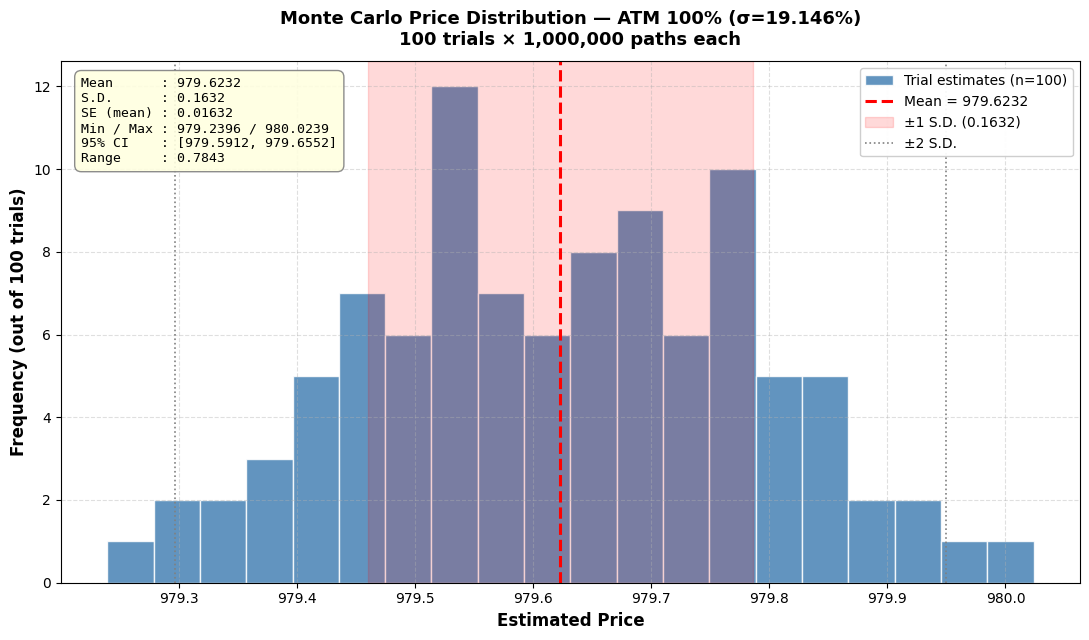

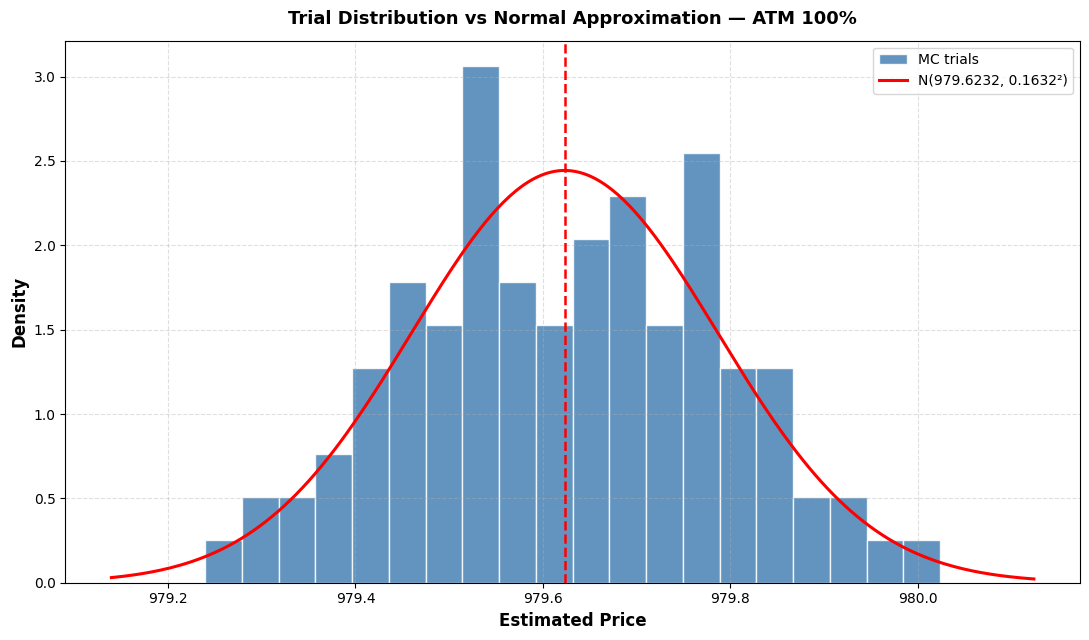

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# ==========================================
# 1. 全域參數設定
# ==========================================
S0 = 6966.28
q  = 0.01186
T  = 790/365

df_1102028 = 0.936750
df_1102029 = 0.906261
df_3092028 = df_1102028 + (df_1102029 - df_1102028) * 59 / 365
r = -np.log(df_3092028) / T
pay_lag_df = np.exp(-r * (5/365))

day_jan30    = 21
day_autocall = 424
day_maturity = 790


# ==========================================
# 2. 單次 MC 引擎（分段大跳 + antithetic）
# ==========================================
def mc_one_trial(sigma, n_paths, seed, antithetic=True):
    rng = np.random.default_rng(seed)

    dt_daily = 1/365
    dt_jump1 = (day_autocall - day_jan30) / 365
    dt_jump2 = (day_maturity - day_autocall) / 365

    drift_d  = (r - q - 0.5*sigma**2) * dt_daily
    vol_d    = sigma * np.sqrt(dt_daily)
    drift_j1 = (r - q - 0.5*sigma**2) * dt_jump1
    vol_j1   = sigma * np.sqrt(dt_jump1)
    drift_j2 = (r - q - 0.5*sigma**2) * dt_jump2
    vol_j2   = sigma * np.sqrt(dt_jump2)

    df_autocall = np.exp(-r * day_autocall / 365) * pay_lag_df
    df_maturity = np.exp(-r * T)                  * pay_lag_df

    if antithetic:
        half = (n_paths + 1) // 2
        Z_look_h = rng.standard_normal((half, day_jan30))
        Z_j1_h   = rng.standard_normal(half)
        Z_j2_h   = rng.standard_normal(half)
        Z_look = np.concatenate([Z_look_h, -Z_look_h], axis=0)[:n_paths]
        Z_j1   = np.concatenate([Z_j1_h,   -Z_j1_h  ])[:n_paths]
        Z_j2   = np.concatenate([Z_j2_h,   -Z_j2_h  ])[:n_paths]
    else:
        Z_look = rng.standard_normal((n_paths, day_jan30))
        Z_j1   = rng.standard_normal(n_paths)
        Z_j2   = rng.standard_normal(n_paths)

    log_S = np.log(S0) + np.cumsum(drift_d + vol_d * Z_look, axis=1)
    S_daily = np.exp(log_S)
    K    = np.minimum(S0, S_daily.min(axis=1))
    S_21 = S_daily[:, -1]
    del Z_look, log_S, S_daily

    S_424 = S_21 * np.exp(drift_j1 + vol_j1 * Z_j1)
    KO    = (S_424 >= K)
    S_T   = S_424 * np.exp(drift_j2 + vol_j2 * Z_j2)

    ratio = S_T / K
    payoff_T = np.where(
        S_T >= K,
        1000 + 1500 * (ratio - 1),
        np.where(S_T >= 0.8*K, 1000.0, 1000.0 * ratio)
    )
    pv = np.where(KO, df_autocall * 1098.50, df_maturity * payoff_T)
    return pv.mean(), pv.std(ddof=1) / np.sqrt(n_paths)


# ==========================================
# 3. 跑 100 trials（ATM benchmark）
# ==========================================
sigma     = 0.19146           # ATM 100% Moneyness
N_TRIALS  = 100
N_PATHS   = 1_000_000

print("="*70)
print(f"Monte Carlo Benchmark — ATM 100% Moneyness")
print(f"  σ                     = {sigma*100:.3f}%")
print(f"  Trials                = {N_TRIALS}")
print(f"  Paths per trial       = {N_PATHS:,}")
print(f"  Total paths           = {N_TRIALS*N_PATHS:,}")
print(f"  Time-stepping         = 21 daily + 2 big jumps")
print(f"  Variance reduction    = antithetic")
print("="*70 + "\n")

prices = np.empty(N_TRIALS)
t_start = time.time()
for tr in range(N_TRIALS):
    p, _ = mc_one_trial(sigma, N_PATHS, seed=tr)
    prices[tr] = p
    if (tr+1) % 10 == 0:
        elapsed = time.time() - t_start
        eta = elapsed / (tr+1) * (N_TRIALS - tr - 1)
        print(f"  trial {tr+1:3d}/{N_TRIALS}  "
              f"running mean = {prices[:tr+1].mean():.4f}  "
              f"elapsed {elapsed:.1f}s  ETA {eta:.1f}s")
total_elapsed = time.time() - t_start


# ==========================================
# 4. 統計量計算
# ==========================================
mean_price = prices.mean()
std_price  = prices.std(ddof=1)            # trial-to-trial std
se_mean    = std_price / np.sqrt(N_TRIALS) # SE of grand mean
ci_low     = mean_price - 1.96 * se_mean
ci_high    = mean_price + 1.96 * se_mean

stats_summary = {
    "Mean":      mean_price,
    "Std (S.D.)":std_price,
    "SE":        se_mean,
    "Min":       prices.min(),
    "Max":       prices.max(),
    "Median":    np.median(prices),
    "95% CI":    f"[{ci_low:.4f}, {ci_high:.4f}]",
    "Range":     prices.max() - prices.min(),
}

print("\n" + "="*70)
print("Statistics across 100 trials:")
for k, v in stats_summary.items():
    if isinstance(v, float):
        print(f"  {k:12s} = {v:.4f}")
    else:
        print(f"  {k:12s} = {v}")
print(f"  Total time   = {total_elapsed:.1f}s")
print("="*70)


# ==========================================
# 5. 畫 Histogram
# ==========================================
fig, ax = plt.subplots(figsize=(11, 6.5))

# 主直方圖
n, bins, patches = ax.hist(
    prices, bins=20, color='steelblue', edgecolor='white',
    alpha=0.85, label='Trial estimates (n=100)'
)

# Mean 線
ax.axvline(mean_price, color='red', linestyle='--', linewidth=2.2,
           label=f'Mean = {mean_price:.4f}')

# ±1 σ 區間
ax.axvspan(mean_price - std_price, mean_price + std_price,
           alpha=0.15, color='red', label=f'±1 S.D. ({std_price:.4f})')

# ±2 σ 線
ax.axvline(mean_price - 2*std_price, color='gray', linestyle=':', linewidth=1.2)
ax.axvline(mean_price + 2*std_price, color='gray', linestyle=':', linewidth=1.2,
           label=f'±2 S.D.')

# 標題與軸標籤
ax.set_title(
    f"Monte Carlo Price Distribution — ATM 100% (σ={sigma*100:.3f}%)\n"
    f"{N_TRIALS} trials × {N_PATHS:,} paths each",
    fontsize=13, fontweight='bold', pad=12
)
ax.set_xlabel("Estimated Price", fontsize=12, fontweight='bold')
ax.set_ylabel("Frequency (out of 100 trials)", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='upper right', fontsize=10, framealpha=0.95)

# 文字框：詳細統計
stats_text = (
    f"Mean      : {mean_price:.4f}\n"
    f"S.D.      : {std_price:.4f}\n"
    f"SE (mean) : {se_mean:.5f}\n"
    f"Min / Max : {prices.min():.4f} / {prices.max():.4f}\n"
    f"95% CI    : [{ci_low:.4f}, {ci_high:.4f}]\n"
    f"Range     : {prices.max() - prices.min():.4f}"
)
ax.text(0.02, 0.97, stats_text,
        transform=ax.transAxes, fontsize=9.5,
        verticalalignment='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.9))

plt.tight_layout()
plt.show()


# ==========================================
# 6. （可選）疊加常態分布看是否近似常態
# ==========================================
fig2, ax2 = plt.subplots(figsize=(11, 6.5))
ax2.hist(prices, bins=20, density=True, color='steelblue',
         edgecolor='white', alpha=0.85, label='MC trials')

# 疊上常態 PDF
x_range = np.linspace(prices.min() - 0.1, prices.max() + 0.1, 300)
from scipy.stats import norm
pdf = norm.pdf(x_range, loc=mean_price, scale=std_price)
ax2.plot(x_range, pdf, 'r-', linewidth=2.2,
         label=f'N({mean_price:.4f}, {std_price:.4f}²)')

ax2.axvline(mean_price, color='red', linestyle='--', linewidth=1.8)
ax2.set_title(
    f"Trial Distribution vs Normal Approximation — ATM 100%",
    fontsize=13, fontweight='bold', pad=12
)
ax2.set_xlabel("Estimated Price", fontsize=12, fontweight='bold')
ax2.set_ylabel("Density", fontsize=12, fontweight='bold')
ax2.grid(True, linestyle='--', alpha=0.4)
ax2.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

Running 4 scenarios × 100 trials × 1,000,000 paths
Estimated total time: ~432s ≈ 7 min


[ATM 100% Moneyness]  σ = 19.146%
   trial  20/100  running mean = 979.5889  ETA 83.0s
   trial  40/100  running mean = 979.6232  ETA 61.4s
   trial  60/100  running mean = 979.5915  ETA 41.4s
   trial  80/100  running mean = 979.6215  ETA 20.9s
   trial 100/100  running mean = 979.6232  ETA 0.0s
   → Mean = 979.6232  ± 0.0320  (std = 0.1632)  耗時 103.4s

[Downside 80% Moneyness]  σ = 23.944%
   trial  20/100  running mean = 960.2751  ETA 81.8s
   trial  40/100  running mean = 960.3068  ETA 59.7s
   trial  60/100  running mean = 960.2685  ETA 40.1s
   trial  80/100  running mean = 960.3013  ETA 19.9s
   trial 100/100  running mean = 960.3006  ETA 0.0s
   → Mean = 960.3006  ± 0.0392  (std = 0.1999)  耗時 100.3s

[Autocall 424D Term]  σ = 17.770%
   trial  20/100  running mean = 985.2622  ETA 81.6s
   trial  40/100  running mean = 985.2982  ETA 59.9s
   trial  60/100  running mean = 985.2686  ETA 39.2s


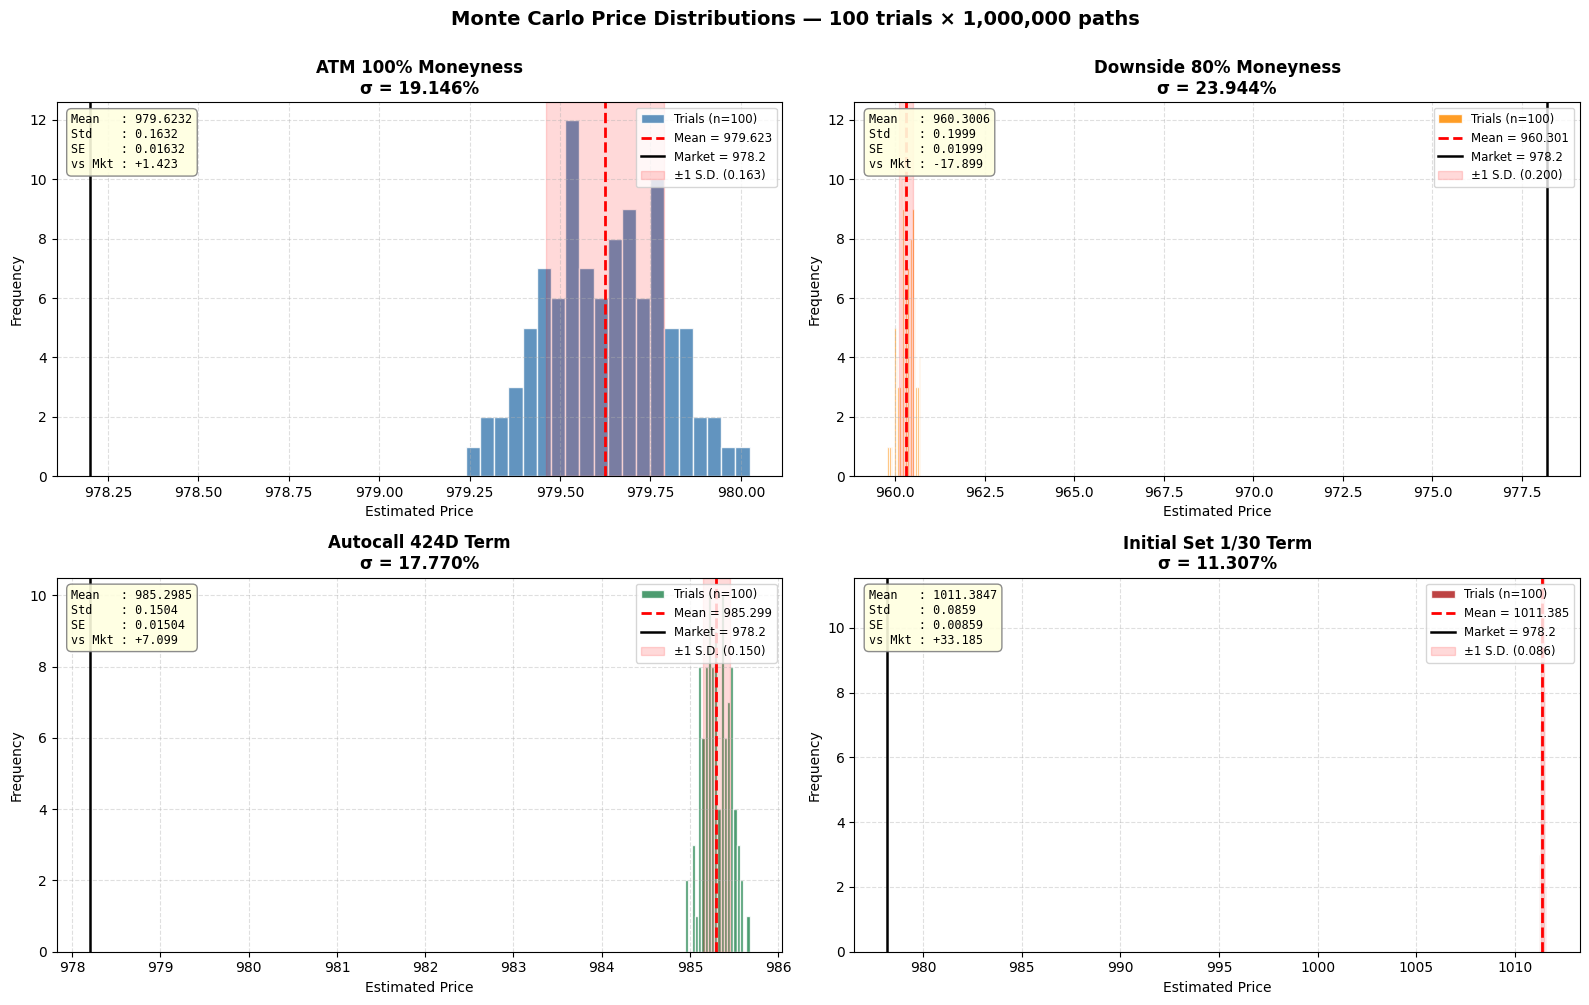

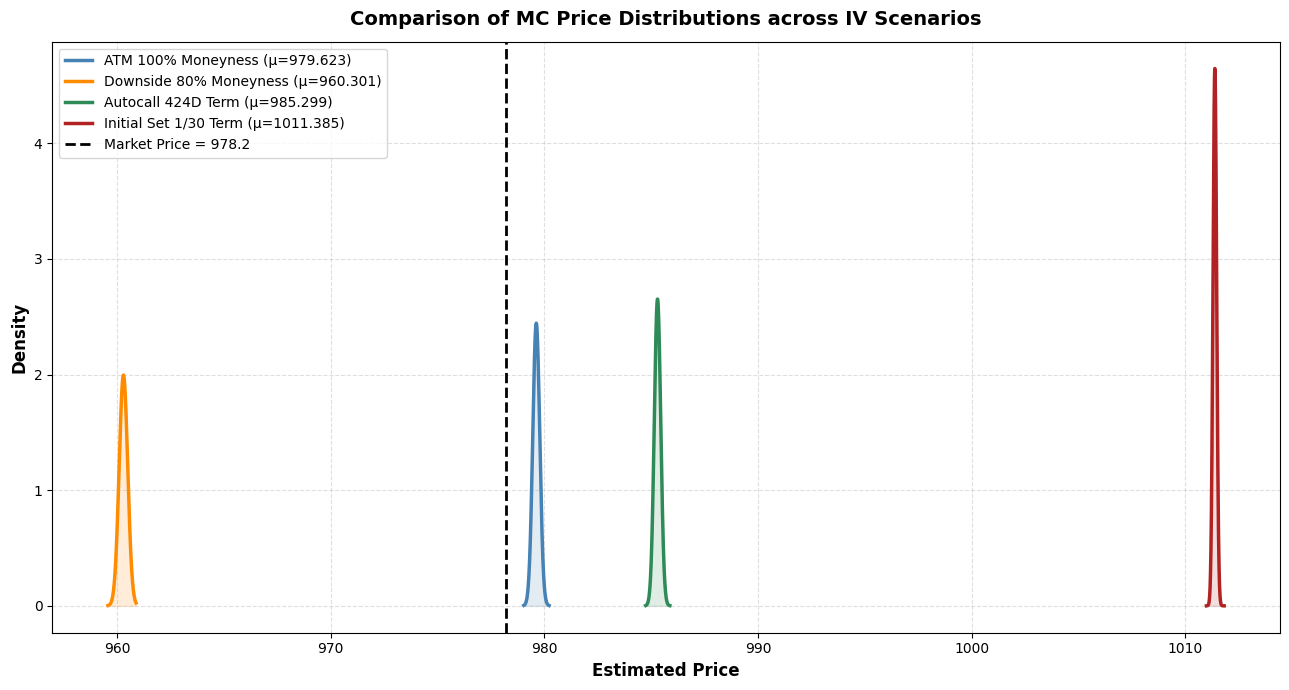

In [ ]:
# ============================================================
# 跑 4 個情境的完整版（100 × 1M each）
# 保留前面已經 define 好的 mc_one_trial 函數
# ============================================================
import matplotlib.pyplot as plt
from scipy.stats import norm

iv_scenarios = {
    "ATM 100% Moneyness":     0.19146,
    "Downside 80% Moneyness": 0.23944,
    "Autocall 424D Term":     0.17770,
    "Initial Set 1/30 Term":  0.11307,
}

N_TRIALS = 100
N_PATHS  = 1_000_000
MARKET_PRICE = 978.20

all_results   = {}      # 存 raw prices array
summary_rows  = []      # 存 summary 表

print("="*70)
print(f"Running 4 scenarios × {N_TRIALS} trials × {N_PATHS:,} paths")
print(f"Estimated total time: ~{4*108}s ≈ 7 min")
print("="*70 + "\n")

start_total = time.time()

for iv_name, sigma in iv_scenarios.items():
    print(f"\n[{iv_name}]  σ = {sigma*100:.3f}%")
    prices = np.empty(N_TRIALS)
    t0 = time.time()

    for tr in range(N_TRIALS):
        p, _ = mc_one_trial(sigma, N_PATHS, seed=tr)
        prices[tr] = p
        if (tr+1) % 20 == 0:
            elapsed = time.time() - t0
            eta = elapsed / (tr+1) * (N_TRIALS - tr - 1)
            print(f"   trial {tr+1:3d}/{N_TRIALS}  "
                  f"running mean = {prices[:tr+1].mean():.4f}  "
                  f"ETA {eta:.1f}s")

    # 統計
    mean_p  = prices.mean()
    std_p   = prices.std(ddof=1)
    se_p    = std_p / np.sqrt(N_TRIALS)
    elapsed = time.time() - t0

    all_results[iv_name] = prices
    summary_rows.append({
        "IV Scenario": iv_name,
        "Sigma":   f"{sigma*100:.3f}%",
        "Mean":    round(mean_p, 4),
        "Std":     round(std_p, 4),
        "SE":      round(se_p, 5),
        "95% CI":  f"[{mean_p-1.96*se_p:.4f}, {mean_p+1.96*se_p:.4f}]",
        "Min":     round(prices.min(), 4),
        "Max":     round(prices.max(), 4),
        "vs Market": round(mean_p - MARKET_PRICE, 2),
        "Time(s)": round(elapsed, 1),
    })

    print(f"   → Mean = {mean_p:.4f}  ± {1.96*se_p:.4f}  "
          f"(std = {std_p:.4f})  耗時 {elapsed:.1f}s")

print(f"\n{'='*70}")
print(f"All scenarios complete. Total time: {time.time()-start_total:.1f}s")
print("="*70)

# ============================================================
# 結果表
# ============================================================
df_summary = pd.DataFrame(summary_rows)
print("\n=== Summary Table ===")
print(df_summary.to_markdown(index=False))


# ============================================================
# 4 合 1 Histogram
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

colors = ['steelblue', 'darkorange', 'seagreen', 'firebrick']

for idx, (iv_name, sigma) in enumerate(iv_scenarios.items()):
    ax = axes[idx]
    prices = all_results[iv_name]
    mean_p = prices.mean()
    std_p  = prices.std(ddof=1)
    se_p   = std_p / np.sqrt(N_TRIALS)

    # 直方圖
    ax.hist(prices, bins=20, color=colors[idx], edgecolor='white',
            alpha=0.85, label=f'Trials (n={N_TRIALS})')

    # Mean、市場價、±1σ
    ax.axvline(mean_p, color='red', linestyle='--', linewidth=2,
               label=f'Mean = {mean_p:.3f}')
    ax.axvline(MARKET_PRICE, color='black', linestyle='-', linewidth=1.8,
               label=f'Market = {MARKET_PRICE}')
    ax.axvspan(mean_p - std_p, mean_p + std_p,
               alpha=0.15, color='red', label=f'±1 S.D. ({std_p:.3f})')

    ax.set_title(f"{iv_name}\nσ = {sigma*100:.3f}%",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel("Estimated Price", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(loc='upper right', fontsize=8.5)

    # 文字框
    stats_text = (
        f"Mean   : {mean_p:.4f}\n"
        f"Std    : {std_p:.4f}\n"
        f"SE     : {se_p:.5f}\n"
        f"vs Mkt : {mean_p - MARKET_PRICE:+.3f}"
    )
    ax.text(0.02, 0.97, stats_text, transform=ax.transAxes, fontsize=8.5,
            verticalalignment='top', family='monospace',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                      edgecolor='gray', alpha=0.9))

plt.suptitle(f"Monte Carlo Price Distributions — {N_TRIALS} trials × {N_PATHS:,} paths",
             fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


# ============================================================
# 4 個情境疊在一張圖（Density 比較）
# ============================================================
fig2, ax = plt.subplots(figsize=(13, 7))
for idx, (iv_name, sigma) in enumerate(iv_scenarios.items()):
    prices = all_results[iv_name]
    mean_p = prices.mean()
    std_p  = prices.std(ddof=1)

    # KDE 平滑分布
    x_range = np.linspace(prices.min() - 0.2, prices.max() + 0.2, 300)
    pdf = norm.pdf(x_range, loc=mean_p, scale=std_p)

    ax.plot(x_range, pdf, color=colors[idx], linewidth=2.5,
            label=f'{iv_name} (μ={mean_p:.3f})')
    ax.fill_between(x_range, pdf, alpha=0.15, color=colors[idx])

ax.axvline(MARKET_PRICE, color='black', linestyle='--', linewidth=2,
           label=f'Market Price = {MARKET_PRICE}')

ax.set_title(f"Comparison of MC Price Distributions across IV Scenarios",
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Estimated Price", fontsize=12, fontweight='bold')
ax.set_ylabel("Density", fontsize=12, fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(loc='best', fontsize=10)

plt.tight_layout()
plt.show()

## path count covergence

Path Count Convergence (σ = 19.146%)
  N =     1,000  mean = 980.3474  SE = 4.85598  t/trial = 0.003s
  N =     2,500  mean = 980.0124  SE = 3.35978  t/trial = 0.005s
  N =     5,000  mean = 979.6952  SE = 1.40292  t/trial = 0.009s
  N =    10,000  mean = 979.8918  SE = 1.79145  t/trial = 0.016s
  N =    25,000  mean = 979.8776  SE = 1.06714  t/trial = 0.037s
  N =    50,000  mean = 979.6467  SE = 0.67199  t/trial = 0.097s
  N =   100,000  mean = 979.6466  SE = 0.54971  t/trial = 0.232s
  N =   250,000  mean = 979.5885  SE = 0.29461  t/trial = 0.456s
  N =   500,000  mean = 979.6547  SE = 0.21605  t/trial = 1.071s
  N = 1,000,000  mean = 979.6447  SE = 0.16652  t/trial = 1.825s

Fitted slope: -0.4858  (theoretical = -0.5000)


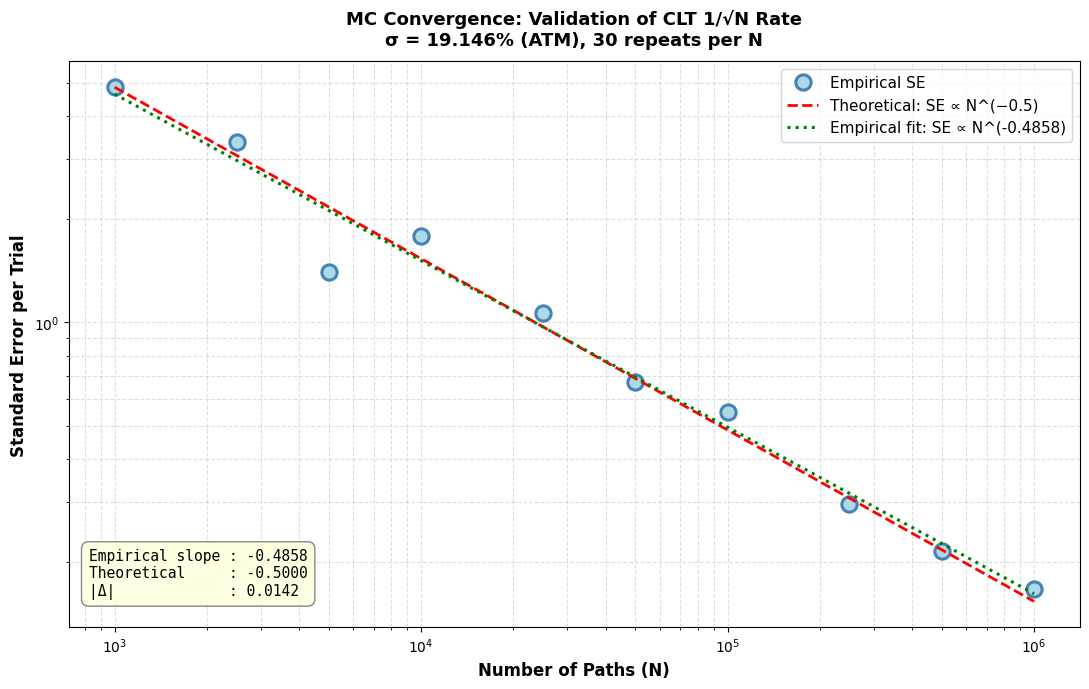

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
r = -np.log(df_3092028) / T
sigma_test = 0.19146
N_values = [1_000, 2_500, 5_000, 10_000, 25_000,
            50_000, 100_000, 250_000, 500_000, 1_000_000]
n_repeats = 30

results_11 = []

print("="*70)
print(f"Path Count Convergence (σ = {sigma_test*100:.3f}%)")
print("="*70)

for N in N_values:
    prices = np.empty(n_repeats)
    t0 = time.time()
    for rep in range(n_repeats):                              # ★ rep 不是 r
        p, _ = mc_one_trial(sigma_test, N, seed=1000 + rep)   # ★
        prices[rep] = p                                        # ★
    elapsed = time.time() - t0

    empirical_mean = prices.mean()
    empirical_std  = prices.std(ddof=1)

    results_11.append({
        "N": N,
        "Mean": round(empirical_mean, 4),
        "Empirical SE": round(empirical_std, 5),
        "Time/trial (s)": round(elapsed / n_repeats, 3),
    })
    print(f"  N = {N:>9,}  mean = {empirical_mean:.4f}  "
          f"SE = {empirical_std:.5f}  t/trial = {elapsed/n_repeats:.3f}s")

# 後面的擬合 + 畫圖完全一樣
N_arr   = np.array([r_["N"]            for r_ in results_11])  # 也改名
SE_arr  = np.array([r_["Empirical SE"] for r_ in results_11])

log_N  = np.log(N_arr)
log_SE = np.log(SE_arr)
slope, intercept = np.polyfit(log_N, log_SE, 1)
print(f"\nFitted slope: {slope:.4f}  (theoretical = -0.5000)")

fig, ax = plt.subplots(figsize=(11, 7))
ax.loglog(N_arr, SE_arr, 'o', markersize=11, color='steelblue',
          markerfacecolor='lightblue', markeredgewidth=2.2, label='Empirical SE')

N_fine = np.logspace(np.log10(N_arr[0]), np.log10(N_arr[-1]), 200)
theory_line = SE_arr[0] * np.sqrt(N_arr[0] / N_fine)
ax.loglog(N_fine, theory_line, '--', color='red', linewidth=2,
          label='Theoretical: SE ∝ N^(−0.5)')

fit_line = np.exp(intercept) * N_fine**slope
ax.loglog(N_fine, fit_line, ':', color='green', linewidth=2.2,
          label=f'Empirical fit: SE ∝ N^({slope:.4f})')

ax.set_xlabel("Number of Paths (N)", fontsize=12, fontweight='bold')
ax.set_ylabel("Standard Error per Trial", fontsize=12, fontweight='bold')
ax.set_title(f"MC Convergence: Validation of CLT 1/√N Rate\n"
             f"σ = {sigma_test*100:.3f}% (ATM), {n_repeats} repeats per N",
             fontsize=13, fontweight='bold', pad=12)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(fontsize=11, loc='upper right')

stats_text = (f"Empirical slope : {slope:.4f}\n"
              f"Theoretical     : -0.5000\n"
              f"|Δ|             : {abs(slope - (-0.5)):.4f}")
ax.text(0.02, 0.05, stats_text, transform=ax.transAxes, fontsize=10.5,
        verticalalignment='bottom', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow',
                  edgecolor='gray', alpha=0.95))

plt.tight_layout()
plt.show()

In [ ]:
print("=== DEBUG ===")
sigma_test = 0.19146

for N in [1_000, 100_000, 1_000_000]:
    prices = []
    for r in range(10):
        p, se_internal = mc_one_trial(sigma_test, N, seed=1000+r)
        prices.append(p)

    prices = np.array(prices)

    print(f"N = {N:>8,}")
    print(f"  prices (10 trials): {prices[:5]}")    # 前 5 個
    print(f"  mean = {prices.mean():.4f}")          # 應該 ~979
    print(f"  std  = {prices.std(ddof=1):.4f}")     # ★ 這個應該隨 N 下降
    print(f"  internal SE (last call): {se_internal:.4f}")
    print()

=== DEBUG ===
N =    1,000
  prices (10 trials): [998.72632157 343.64533859 107.55112302  33.66041311  10.53474273]
  mean = 149.8903
  std  = 316.8769
  internal SE (last call): 0.0000

N =  100,000
  prices (10 trials): [995.8618539  343.64533859 107.55112302  33.66041311  10.53474273]
  mean = 149.6038
  std  = 316.0245
  internal SE (last call): 0.0000

N = 1,000,000
  prices (10 trials): [996.891429   343.64533859 107.55112302  33.66041311  10.53474273]
  mean = 149.7068
  std  = 316.3308
  internal SE (last call): 0.0000



CRR — Convergence
  CRR N =   100  Price = 972.7515  Time = 0.01s
  CRR N =   200  Price = 978.2220  Time = 0.07s
  CRR N =   395  Price = 979.1167  Time = 0.67s
  CRR N =   790  Price = 980.6271  Time = 6.98s
  CRR N =  1580  Price = 980.8292  Time = 24.17s

MC — Convergence
  MC  N =      1,000  Price = 979.7685  SE = 2.11186  T/trial = 0.001s
  MC  N =      5,000  Price = 980.1380  SE = 0.53259  T/trial = 0.004s
  MC  N =     25,000  Price = 979.4763  SE = 0.31564  T/trial = 0.020s
  MC  N =    100,000  Price = 979.5388  SE = 0.14399  T/trial = 0.092s
  MC  N =    500,000  Price = 979.7875  SE = 0.05378  T/trial = 0.463s
  MC  N =  2,000,000  Price = 979.6260  SE = 0.01653  T/trial = 1.964s

=== CRR ===
|    N |   Price |   Time(s) |
|-----:|--------:|----------:|
|  100 | 972.751 |     0.01  |
|  200 | 978.222 |     0.067 |
|  395 | 979.117 |     0.67  |
|  790 | 980.627 |     6.979 |
| 1580 | 980.829 |    24.167 |

=== MC ===
|          N |   Price |      SE |   Time/trial(s) |
|-

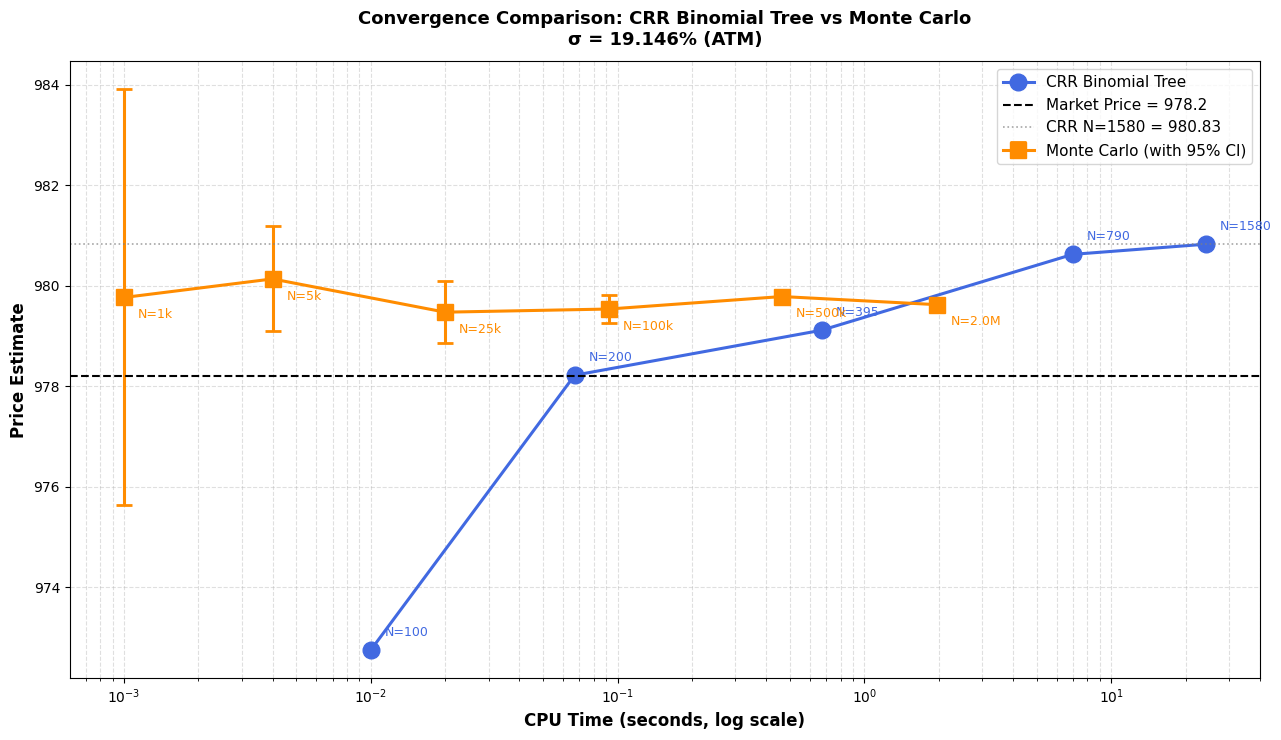

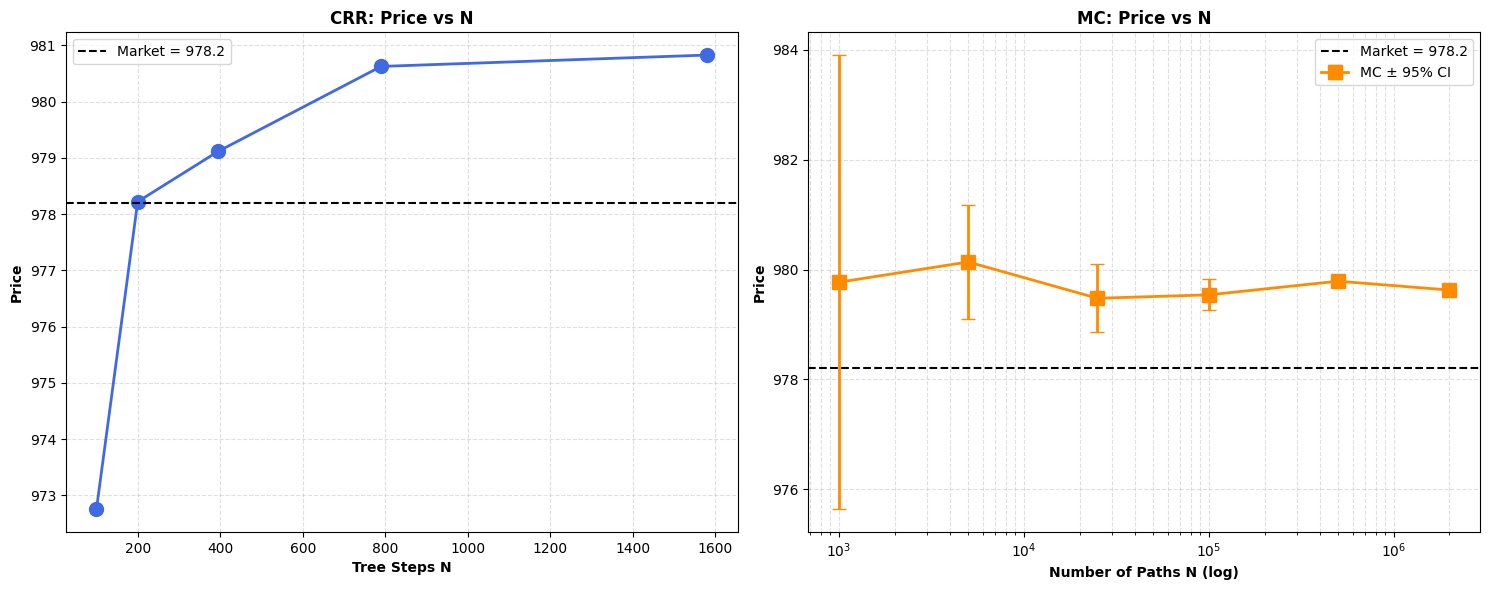

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# === 設定 ===
sigma_test = 0.19146
MARKET_PRICE = 978.20

crr_N_values = [100, 200, 395, 790, 1580]
mc_N_values = [1_000, 5_000, 25_000, 100_000, 500_000, 2_000_000]
mc_n_repeats = 5


# === CRR ===
print("="*70)
print("CRR — Convergence")
print("="*70)
crr_results = []
for N in crr_N_values:
    t0 = time.time()
    price = calculate_crr_price_fast(sigma_test, N)
    elapsed = time.time() - t0
    crr_results.append({"N": N, "Price": round(price, 4),
                         "Time(s)": round(elapsed, 3)})
    print(f"  CRR N = {N:>5d}  Price = {price:.4f}  Time = {elapsed:.2f}s")


# === MC ===
print("\n" + "="*70)
print("MC — Convergence")
print("="*70)
mc_results = []
for N in mc_N_values:
    prices = np.empty(mc_n_repeats)
    t0 = time.time()
    for rep in range(mc_n_repeats):                          # ★ r → rep
        p, _ = mc_one_trial(sigma_test, N, seed=2000 + rep)  # ★
        prices[rep] = p                                       # ★
    elapsed = time.time() - t0

    mean_p = prices.mean()
    se_p   = prices.std(ddof=1) / np.sqrt(mc_n_repeats)
    mc_results.append({
        "N": N,
        "Price": round(mean_p, 4),
        "SE": round(se_p, 5),
        "Time/trial(s)": round(elapsed / mc_n_repeats, 3),
    })
    print(f"  MC  N = {N:>10,}  Price = {mean_p:.4f}  "
          f"SE = {se_p:.5f}  T/trial = {elapsed/mc_n_repeats:.3f}s")


# === 表格 ===
print("\n=== CRR ===")
print(pd.DataFrame(crr_results).to_markdown(index=False))
print("\n=== MC ===")
print(pd.DataFrame(mc_results).to_markdown(index=False))


# === 畫圖：x = CPU time, y = price ===
fig, ax = plt.subplots(figsize=(13, 7.5))

# CRR
crr_times  = [d["Time(s)"] for d in crr_results]              # ★ r → d
crr_prices = [d["Price"]   for d in crr_results]              # ★
ax.plot(crr_times, crr_prices, 'o-', color='royalblue', markersize=12,
        linewidth=2.2, label='CRR Binomial Tree')
for d in crr_results:                                          # ★ r → d
    ax.annotate(f"N={d['N']}", (d["Time(s)"], d["Price"]),
                textcoords="offset points", xytext=(10, 10),
                fontsize=9, color='royalblue')

# MC with 95% CI
mc_times  = [d["Time/trial(s)"] for d in mc_results]          # ★
mc_prices = [d["Price"]         for d in mc_results]          # ★
mc_ses    = [d["SE"]            for d in mc_results]          # ★
ax.errorbar(mc_times, mc_prices, yerr=[1.96*se for se in mc_ses],
            fmt='s-', color='darkorange', markersize=12, linewidth=2.2,
            capsize=6, capthick=2, label='Monte Carlo (with 95% CI)')
for d in mc_results:                                           # ★
    label = f"N={d['N']/1000:.0f}k" if d['N'] < 1_000_000 else f"N={d['N']/1_000_000:.1f}M"
    ax.annotate(label, (d["Time/trial(s)"], d["Price"]),
                textcoords="offset points", xytext=(10, -15),
                fontsize=9, color='darkorange')

ax.axhline(MARKET_PRICE, color='black', linestyle='--', linewidth=1.5,
           label=f'Market Price = {MARKET_PRICE}')
ax.axhline(crr_results[-1]["Price"], color='gray', linestyle=':', linewidth=1.2,
           alpha=0.7, label=f'CRR N={crr_results[-1]["N"]} = {crr_results[-1]["Price"]:.2f}')

ax.set_xscale('log')
ax.set_xlabel("CPU Time (seconds, log scale)", fontsize=12, fontweight='bold')
ax.set_ylabel("Price Estimate", fontsize=12, fontweight='bold')
ax.set_title(f"Convergence Comparison: CRR Binomial Tree vs Monte Carlo\n"
             f"σ = {sigma_test*100:.3f}% (ATM)",
             fontsize=13, fontweight='bold', pad=12)
ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend(fontsize=11, loc='best')

plt.tight_layout()
plt.show()


# === 第二張圖：price vs N ===
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.plot([d["N"] for d in crr_results], [d["Price"] for d in crr_results],   # ★
         'o-', color='royalblue', markersize=10, linewidth=2)
ax1.axhline(MARKET_PRICE, color='black', linestyle='--', label=f'Market = {MARKET_PRICE}')
ax1.set_xlabel("Tree Steps N", fontweight='bold')
ax1.set_ylabel("Price", fontweight='bold')
ax1.set_title("CRR: Price vs N", fontweight='bold')
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.legend()

mc_N_arr     = np.array([d["N"]      for d in mc_results])     # ★
mc_price_arr = np.array([d["Price"]  for d in mc_results])     # ★
mc_se_arr    = np.array([d["SE"]     for d in mc_results])     # ★
ax2.errorbar(mc_N_arr, mc_price_arr, yerr=1.96*mc_se_arr,
             fmt='s-', color='darkorange', markersize=10, linewidth=2,
             capsize=5, label='MC ± 95% CI')
ax2.axhline(MARKET_PRICE, color='black', linestyle='--', label=f'Market = {MARKET_PRICE}')
ax2.set_xscale('log')
ax2.set_xlabel("Number of Paths N (log)", fontweight='bold')
ax2.set_ylabel("Price", fontweight='bold')
ax2.set_title("MC: Price vs N", fontweight='bold')
ax2.grid(True, which='both', linestyle='--', alpha=0.4)
ax2.legend()

plt.tight_layout()
plt.show()